# IMDb Sentiment Classification with Naive Bayes

This notebook evaluates a Multinomial Naive Bayes baseline for IMDb sentiment classification, then examines its sensitivity to word order and compares it with a pre-trained word-embedding model.

## 1. Method

Multinomial Naive Bayes estimates how likely each word is to occur in positive and negative reviews. The predicted class is the one with the higher posterior probability. Laplace smoothing is used to avoid zero probabilities.

In [1]:
# Install required packages if needed.
%pip install -q datasets pandas numpy scikit-learn matplotlib seaborn gensim

Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

SEED = 42
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')

## 2. Load and split the data

Twenty percent of the official training set is used for validation. The official test set is kept unchanged for final evaluation.

In [3]:
dataset = load_dataset('Kwaai/IMDB_Sentiment')
train_full_df = dataset['train'].to_pandas()[['text', 'label']].dropna().copy()
test_df = dataset['test'].to_pandas()[['text', 'label']].dropna().copy()
train_full_df['label'] = train_full_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)

train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_full_df['label']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f'Training reviews: {len(train_df):,}')
print(f'Validation reviews: {len(val_df):,}')
print(f'Test reviews:     {len(test_df):,}')
display(train_df['label'].value_counts().sort_index().rename(index={0: 'negative', 1: 'positive'}))
display(train_df.head(3))

Training reviews: 20,000
Validation reviews: 5,000
Test reviews:     25,000


label
negative    10000
positive    10000
Name: count, dtype: int64

,text,label
0,"I have always been a huge James Bond fanatic! I have seen almost all of the films except for Die Another Day, and The World Is Not Enough. The graphic's for...",1
1,"I am a Christian and I say this movie had terrible acting, unreal situations and a completely facade front for Christianity. You might as well watch ""Rememb...",0
2,"Neatly sandwiched between THE STRANGER, a small film noir picture that proved Welles can do a formidable genre work on budget and on time and ironically pro...",1


## 3. Exploratory data analysis

The split sizes, class balance, and review-length distributions are inspected before modelling. Review length is measured as whitespace-separated tokens in the original review text.

label,Negative,Positive,Total
split,,,
Test,12500,12500,25000
Train,10000,10000,20000
Validation,2500,2500,5000


count   mean    std   min    25%    50%    75%     max
split      label                                                             
Test       Negative  12500.0  228.1  163.2   4.0  127.0  173.5  278.0  1090.0
           Positive  12500.0  229.0  174.4  10.0  124.0  170.0  276.0  2278.0
Train      Negative  10000.0  230.6  166.5  10.0  128.0  175.0  277.2  1522.0
           Positive  10000.0  235.7  179.8  12.0  125.0  174.0  289.0  2470.0
Validation Negative   2500.0  232.1  167.2  22.0  128.0  173.0  281.2  1376.0
           Positive   2500.0  240.7  183.4  18.0  126.0  175.5  296.2  1398.0

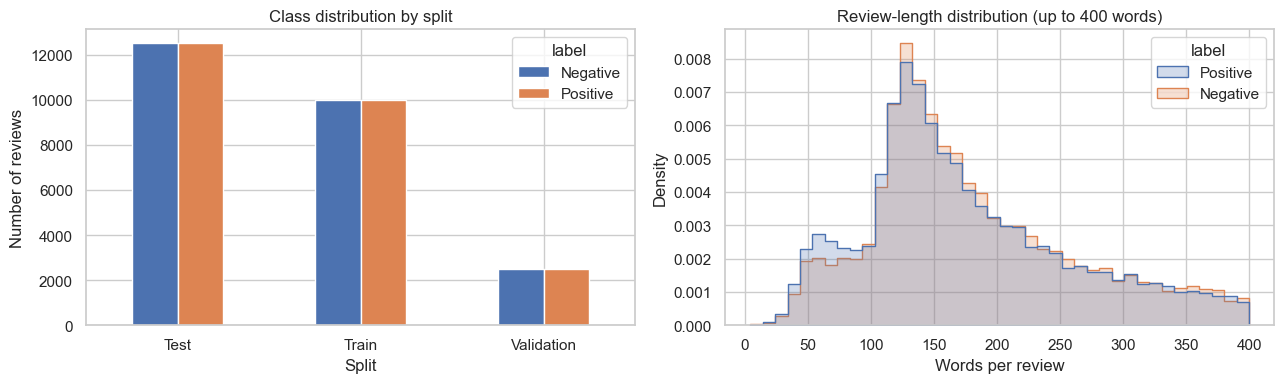

In [4]:
split_frames = {
    'Train': train_df,
    'Validation': val_df,
    'Test': test_df,
}

class_distribution = (
    pd.concat(
        [
            frame.assign(split=split_name)
            for split_name, frame in split_frames.items()
        ],
        ignore_index=True,
    )
    .groupby(['split', 'label'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'Negative', 1: 'Positive'})
)
class_distribution['Total'] = class_distribution.sum(axis=1)
display(class_distribution)

review_lengths = pd.concat(
    [
        pd.DataFrame({
            'split': split_name,
            'label': frame['label'].map({0: 'Negative', 1: 'Positive'}),
            'word_count': frame['text'].str.split().str.len(),
        })
        for split_name, frame in split_frames.items()
    ],
    ignore_index=True,
)
display(review_lengths.groupby(['split', 'label'])['word_count'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
class_distribution[['Negative', 'Positive']].plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Class distribution by split')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Number of reviews')
axes[0].tick_params(axis='x', rotation=0)

sns.histplot(
    data=review_lengths.query("word_count <= 400"),
    x='word_count', hue='label', bins=40, stat='density', common_norm=False,
    element='step', ax=axes[1],
)
axes[1].set_title('Review-length distribution (up to 400 words)')
axes[1].set_xlabel('Words per review')
plt.tight_layout()
plt.show()

## 4. Text cleaning

The reviews are converted to lowercase, HTML line breaks are removed, and repeated spaces are normalised. Negation words are kept.

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

train_df['clean_text'] = train_df['text'].map(clean_text)
val_df['clean_text'] = val_df['text'].map(clean_text)
test_df['clean_text'] = test_df['text'].map(clean_text)
print(train_df.loc[0, 'clean_text'][:500])

i have always been a huge james bond fanatic! i have seen almost all of the films except for die another day, and the world is not enough. the graphic's for everything or nothing are breathtaking! the voice talents......... wow! i love pierce brosnan! he is finally bond in a video game! he is bond! i enjoyed the past bond games: goldeneye, the world is not enough, agent under fire, and nightfire. this one is definitely the best! finally, mr. brosnan, (may i call him mr. brosnan as a sign of resp


## 5. Validation-based feature selection

The validation set compares a unigram-only count representation with a unigram-plus-consecutive-bigram representation. The setting with the highest validation F1 score is selected before the final model is retrained using the combined training and validation data.

In [6]:
feature_candidates = [
    {'name': 'Unigram only', 'ngram_range': (1, 1)},
    {'name': 'Unigram + consecutive bigram', 'ngram_range': (1, 2)},
]

validation_rows = []
for candidate in feature_candidates:
    validation_vectorizer = CountVectorizer(
        max_features=20_000,
        ngram_range=candidate['ngram_range'],
        min_df=2,
        max_df=0.95,
    )
    X_train_dev = validation_vectorizer.fit_transform(train_df['clean_text'])
    X_val = validation_vectorizer.transform(val_df['clean_text'])
    validation_model = MultinomialNB(alpha=1.0).fit(X_train_dev, train_df['label'])
    y_val_pred = validation_model.predict(X_val)
    validation_rows.append({
        'feature_setting': candidate['name'],
        'ngram_range': candidate['ngram_range'],
        'validation_accuracy': accuracy_score(val_df['label'], y_val_pred),
        'validation_f1': f1_score(val_df['label'], y_val_pred),
        'vocabulary_size': X_train_dev.shape[1],
    })

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values('validation_f1', ascending=False)
    .reset_index(drop=True)
)
selected_setting = validation_results.iloc[0]
display(validation_results.round(4))
print(f"Selected setting: {selected_setting['feature_setting']}")

,feature_setting,ngram_range,validation_accuracy,validation_f1,vocabulary_size
0,Unigram + consecutive bigram,"(1, 2)",0.857,0.8558,20000
1,Unigram only,"(1, 1)",0.841,0.8353,20000


Selected setting: Unigram + consecutive bigram


## 6. Final feature extraction

After selecting the feature setting on the validation set, the training and validation subsets are recombined to fit the final vectorizer. The official test set remains untouched until final evaluation.

In [7]:
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

vectorizer = CountVectorizer(
    max_features=20_000,
    ngram_range=selected_setting['ngram_range'],
    min_df=2,
    max_df=0.95,
)

vector_start = time.perf_counter()
X_train = vectorizer.fit_transform(train_val_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])
vector_time = time.perf_counter() - vector_start

print(f"Selected feature setting: {selected_setting['feature_setting']}")
print('Final training matrix shape:', X_train.shape)
print('Test matrix shape:          ', X_test.shape)
print(f'Vectorisation time:   {vector_time:.3f} seconds')
print('First 20 vocabulary features:')
print(vectorizer.get_feature_names_out()[:20])

Selected feature setting: Unigram + consecutive bigram
Final training matrix shape: (25000, 20000)
Test matrix shape:           (25000, 20000)
Vectorisation time:   29.592 seconds
First 20 vocabulary features:
['00' '000' '10' '10 10' '10 and' '10 because' '10 but' '10 for' '10 it'
 '10 lines' '10 minutes' '10 out' '10 stars' '10 the' '10 year' '10 years'
 '100' '101' '11' '12']


## 7. Train and evaluate the Naive Bayes baseline

The final Naive Bayes baseline uses standard Laplace smoothing with `alpha=1.0` and the feature setting selected on the validation set.

In [8]:
model = MultinomialNB(alpha=1.0)

train_start = time.perf_counter()
model.fit(X_train, train_val_df['label'])
training_time = time.perf_counter() - train_start

predict_start = time.perf_counter()
y_pred = model.predict(X_test)
prediction_time = time.perf_counter() - predict_start

results = pd.Series({
    'alpha': 1.0,
    'accuracy': accuracy_score(test_df['label'], y_pred),
    'precision': precision_score(test_df['label'], y_pred),
    'recall': recall_score(test_df['label'], y_pred),
    'f1': f1_score(test_df['label'], y_pred),
    'vectorisation_time_s': vector_time,
    'training_time_s': training_time,
    'prediction_time_s': prediction_time,
    'vocabulary_size': X_train.shape[1],
})
display(results.to_frame('value'))
print(classification_report(
    test_df['label'], y_pred,
    target_names=['Negative', 'Positive'], digits=4
))

,value
alpha,1.000000
accuracy,0.849160
precision,0.861989
recall,0.831440
f1,0.846439
vectorisation_time_s,29.591507
training_time_s,0.060115
prediction_time_s,0.037437
vocabulary_size,20000.000000


              precision    recall  f1-score   support

    Negative     0.8372    0.8669    0.8518     12500
    Positive     0.8620    0.8314    0.8464     12500

    accuracy                         0.8492     25000
   macro avg     0.8496    0.8492    0.8491     25000
weighted avg     0.8496    0.8492    0.8491     25000



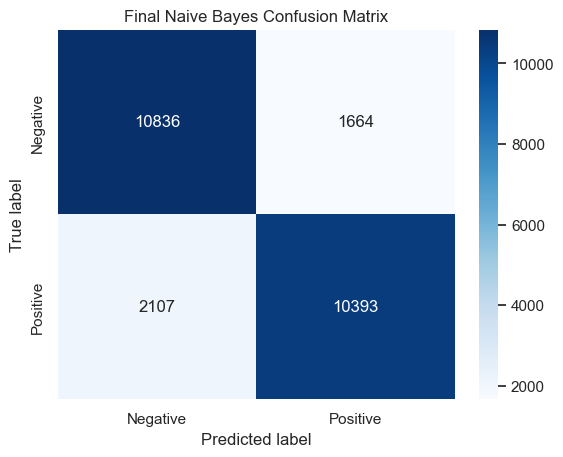

In [9]:
cm = confusion_matrix(test_df['label'], y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Final Naive Bayes Confusion Matrix')
plt.show()

## 8. Word-order shuffle experiment

Each test review is shuffled once using a fixed seed, while preserving its words and label. A pure unigram bag-of-words model would be invariant to this transformation. This baseline also uses consecutive bigrams, so any performance decrease measures its reliance on local word order.

In [10]:
def shuffle_words(text, rng):
    words = str(text).split()
    rng.shuffle(words)
    return ' '.join(words)

shuffle_rng = np.random.default_rng(SEED)
shuffled_test_text = test_df['clean_text'].map(
    lambda text: shuffle_words(text, shuffle_rng)
)
X_test_shuffled = vectorizer.transform(shuffled_test_text)
y_pred_shuffled = model.predict(X_test_shuffled)

shuffle_results = pd.DataFrame([
    {
        'test_condition': 'Original review',
        'accuracy': accuracy_score(test_df['label'], y_pred),
        'precision': precision_score(test_df['label'], y_pred),
        'recall': recall_score(test_df['label'], y_pred),
        'f1': f1_score(test_df['label'], y_pred),
    },
    {
        'test_condition': 'Words shuffled',
        'accuracy': accuracy_score(test_df['label'], y_pred_shuffled),
        'precision': precision_score(test_df['label'], y_pred_shuffled),
        'recall': recall_score(test_df['label'], y_pred_shuffled),
        'f1': f1_score(test_df['label'], y_pred_shuffled),
    },
]).set_index('test_condition')
shuffle_results['f1_change_from_original'] = shuffle_results['f1'] - shuffle_results.loc['Original review', 'f1']
display(shuffle_results.round(4))

,accuracy,precision,recall,f1,f1_change_from_original
test_condition,,,,,
Original review,0.8492,0.8620,0.8314,0.8464,0.0000
Words shuffled,0.8217,0.8324,0.8056,0.8188,-0.0276


## 9. Important features

Feature scores are calculated from the difference between positive and negative log probabilities. To avoid highlighting rare movie titles, only features appearing in at least 20 training reviews are displayed.

In [11]:
feature_names = np.asarray(vectorizer.get_feature_names_out())
sentiment_score = model.feature_log_prob_[1] - model.feature_log_prob_[0]
document_frequency = np.asarray(X_train.getnnz(axis=0)).ravel()
eligible_idx = np.flatnonzero(document_frequency >= 20)
top_positive_idx = eligible_idx[np.argsort(sentiment_score[eligible_idx])[-15:][::-1]]
top_negative_idx = eligible_idx[np.argsort(sentiment_score[eligible_idx])[:15]]

important_features = pd.DataFrame({
    'positive_feature': feature_names[top_positive_idx],
    'positive_score': sentiment_score[top_positive_idx],
    'positive_document_frequency': document_frequency[top_positive_idx],
    'negative_feature': feature_names[top_negative_idx],
    'negative_score': sentiment_score[top_negative_idx],
    'negative_document_frequency': document_frequency[top_negative_idx],
})
display(important_features)

,positive_feature,positive_score,positive_document_frequency,negative_feature,negative_score,negative_document_frequency
0,edie,4.695917,40,this garbage,-4.348369,72
1,antwone,4.484073,24,boll,-4.281230,59
2,din,4.414277,25,terrible movie,-4.224071,67
3,gunga,4.200129,23,prom night,-4.209256,30
4,goldsworthy,4.185091,21,this turkey,-4.147698,59
5,gunga din,4.169824,23,even worth,-4.115437,59
6,paulie,4.081413,38,worst films,-4.011897,107
7,visconti,3.946680,21,uwe,-3.936389,57
8,rob roy,3.779626,20,this crap,-3.936389,145
9,midnight cowboy,3.445424,31,slater,-3.916587,24


## 10. Error examples

A small sample of incorrect predictions is shown for manual inspection.

In [12]:
error_examples = test_df[['text', 'label']].copy()
error_examples['prediction'] = y_pred
error_examples = error_examples[
    error_examples['label'] != error_examples['prediction']
].copy()
display(error_examples.sample(min(8, len(error_examples)), random_state=SEED))

,text,label,prediction
2076,"I do not know which one was first released earlier in 1970 . Cannon for Cordoba is an ""Europen Western"" It was made in Spain. This means this is fairly infe...",0,1
15112,"This movie is such a fine example of the greatness that is 80's entertainment. Oh don't get me wrong, most of the music back then sucked. I only ever liked ...",1,0
24466,Scary in places though the effects did leave something to be desired unless you have bad eyesight or are afraid of the dark. However most of the acting was ...,1,0
18781,"It gives the ordinary guy/girl the chance to be on television singing as their favourite stars.<br /><br />For the majority of the time, they sound like the...",1,0
12661,"The funniest show ever on TV, albeit the humor is not for everyone. I realize it would have been hard to keep the show fresh if it had ran longer, but it's ...",1,0
9022,"Even die hard John Wayne fans will have to concede that this film is a mess. Wayne's character, John Tobin is after the gang that killed his parents, led by...",0,1
17208,"There is no denying that this is a bad movie. The acting isn't great, likewise the script, acting and direction. Still, I cannot wait until its 2/23/99 vide...",1,0
4298,"This version of Mansfield Park, while being extremely accurate to the novel lacked the compassion I felt for Fanny which is crucial and central to this Jane...",0,1


## 11. Discussion and possible extensions

The count-based Naive Bayes model is fast and directly interpretable through its word-feature scores. Its unigram or unigram-plus-bigram representation is selected using validation F1 before final test evaluation. The shuffle experiment isolates the value of consecutive bigrams: a decrease in performance after shuffling indicates reliance on local word order. The GloVe comparison tests whether a compact semantic representation is competitive with explicit word counts. When interpreting the final tables, discuss the observed trade-off between F1 score, computational cost, dimensionality, and interpretability.

Co-occurrence features, SVD, and text summarisation are deliberately not included in this minimal extension. Fine-tuning is also not used: GloVe remains a fixed pre-trained embedding, while fine-tuning would require a trainable neural model and a substantially different experimental setup. These are possible future work, but each would extend the scope beyond the controlled comparisons above.

### References

- Pang, B., Lee, L., & Vaithyanathan, S. (2002). *Thumbs up? Sentiment classification using machine learning techniques*. EMNLP 2002, 79-86. https://aclanthology.org/W02-1011/
- Maas, A. L., et al. (2011). *Learning word vectors for sentiment analysis*. ACL-HLT 2011, 142-150. https://ai.stanford.edu/~ang/papers/acl11-WordVectorsSentimentAnalysis.pdf
- Pennington, J., Socher, R., & Manning, C. D. (2014). *GloVe: Global Vectors for Word Representation*. EMNLP 2014, 1532-1543. https://aclanthology.org/D14-1162/